In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [21]:
def extract_subimage(img, frame_percentage):
    """
    Extrae una imagen de M1 x N1 centrada en la imagen original.

    Args:
    img (np.ndarray): Imagen original de la cual se extraerá la subimagen.
    frame_percentage (float): Porcentaje de la imagen original a utilizar para la subimagen. Debe estar entre 0 y 1 (exclusivo).
    
    Returns:
    np.ndarray: Subimagen extraída centrada en la imagen original.

    """

    if frame_percentage <= 0 or frame_percentage >= 1:
        return img

    # Extraer una subimagen centrada con el porcentaje especificado
    M1, N1 = int(img.shape[0] * frame_percentage), int(img.shape[1] * frame_percentage)

    M, N = img.shape
    
    # Calcular el centro de la imagen original  
    center_m, center_n = M // 2, N // 2
    
    # Calcular los límites superior, inferior, izquierdo y derecho
    # Se utiliza división entera para asegurar índices válidos
    m_start= center_m - M1 // 2
    m_end = m_start + M1
    
    n_start = center_n - N1 // 2
    n_end = n_start + N1
    
    # Extraer la submatriz
    subimage = img[m_start:m_end, n_start:n_end]
    
    return subimage

In [22]:
def calculate_fm(image_gray : np.ndarray, frame_percentage : float = 1.0) -> float:
    '''
    Implementa el algoritmo propuesto en el paper 'Image Sharpness Measure for Blurred in Frequency Domain'

    Args:
        image_gray (np.ndarray): Imagen en escala de grises a procesar
        frame_percentage (float): Porcentaje de la imagen original a utilizar para el cálculo del índice de enfoque. 
                                 Si es 1.0 se utiliza la imagen completa, si es menor se utiliza una subimagen centrada.
    Returns:
        float: Índice de enfoque calculado para la imagen dada

    '''
    image_gray = extract_subimage(image_gray, frame_percentage)

    ft = np.fft.fft2(image_gray)
 
    ft_shifted = np.fft.fftshift(ft)
 
    magnitude = np.abs(ft_shifted)
 
    af = np.max(magnitude)
 
    # Valor propuesto en el paper
    thres = af / 1000

    # Contar la cantidad de componentes cuya magnitud es mayor que el umbral
    th = np.sum(magnitude > thres)

    row, cols = image_gray.shape

    # Calcular el índice de enfoque de la imagen y devolverlo
    return th / (row * cols)

In [23]:

def count_values_above_threshold(fm_values : np.ndarray, fm_max_value: float, thres : float) -> int:
    '''
    Cuenta la cantidad de componentes cuya magnitud es mayor que el umbral dado

    Args:
        fm_values (np.ndarray): Valores fm a procesar
        fm_max_value (float): Valor máximo del espectro de magnitud
        thres (float): Umbral para contar los componentes

    Returns:
        int: Cantidad de componentes cuya magnitud es mayor que el umbral
    '''
    return np.sum(fm_values > fm_max_value * (1 - thres))

In [24]:

def calculate_fm_from_video(video_path : str, frame_percentage : float = 1.0, sharp_image : bool = False, thres = 0.2) -> list[float]:
    '''
    Calcula el índice de enfoque de cada frame del video y devuelve una lista con los resultados

    Args:
        video_path (str): Ruta al video a procesar
        frame_percentage (float): Porcentaje de la imagen original a utilizar para el cálculo del índice de enfoque. 
                                 Si es 1.0 se utiliza la imagen completa, si es menor se utiliza una subimagen centrada.
        sharpen_image (bool): Indica si se debe aplicar un filtro de enfoque a la imagen antes del cálculo.

    '''
    cap = cv2.VideoCapture(video_path)
    fm_values = []
    gray_frames = [] 
    while True:
        
        # Recuperar el siguiente frame disponible 
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convertir el frame a escala de grises y aplicar el filtro de enfoque si se indicó
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
       
        # Calcular el índice de enfoque para el frame actual y agregarlo a la lista de resultados
        fm_value = calculate_fm(gray_frame, frame_percentage)
        fm_values.append(fm_value)
        gray_frames.append(gray_frame)
    cap.release()

    max_fm_value = max(fm_values)
    max_fm_index = fm_values.index(max_fm_value)

    # Si se indico que se desea aplicar el sharpening, si el fm original del frame es mayor que el umbral se 
    # recalcula el fm utilizando la imagen con el filtro de enfoque aplicado
    sharpen_indexes = []
    if sharp_image:
        for i, gray_frame in enumerate(gray_frames):
            if i == max_fm_index:
                print(f"Skipping max fm frame: {max_fm_index}")
                continue
            if max_fm_value * (1-thres) < fm_values[i]:
                fm_values[i] = calculate_fm(sharpen_image(gray_frame))
                sharpen_indexes.append(i)

    data = {
        'fm_values': fm_values,
        'max_fm_value': max_fm_value,
        'max_fm_index': max_fm_index,
        'max_fm_frame': cap.get(cv2.CAP_PROP_POS_FRAMES) - len(fm_values) + max_fm_index,
        'values_above_threshold': count_values_above_threshold(np.array(fm_values), max_fm_value, thres),
        'sharpen_indexes' : sharpen_indexes
    }

    return data

In [25]:
def plot_fm_values(fm_values : list[float]) -> None:
    '''
    Grafica los valores del índice de enfoque a lo largo del tiempo

    Args:        fm_values (list[float]): Lista con los valores del índice de enfoque a lo largo del tiempo
    '''
    plt.figure(figsize=(10, 6))
    plt.plot(fm_values)
    
    # Encontrar el índice y valor máximo
    max_idx = np.argmax(fm_values)
    max_value = fm_values[max_idx]
    
    # Agregar línea vertical en el máximo
    plt.axvline(x=max_idx, color='r', linestyle='--', linewidth=2, label=f'Máximo: {max_value:.6f}')
    
    # Agregar texto con el valor máximo
    plt.text(max_idx, max_value, f'  Frame: {max_idx}, FM: {max_value:.6f}', verticalalignment='bottom', color='red', fontsize=10, fontweight='bold')
    
    plt.xlabel('Indice del Frame')
    plt.ylabel('Focus Measure')
    plt.title('Focus Measure vs Indice del Frame')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [26]:
def sharpen_image(image : np.ndarray) -> np.ndarray:
    '''
    Aplica un filtro de enfoque a la imagen dada 

    Args:
    image (np.ndarray): Imagen en escala de grises a procesar

    '''
    k = 0.5
    sigma = 0.3
    kernel_size = (3, 3)
    img_float = image.astype(np.float32)
    image_low = cv2.GaussianBlur(img_float, kernel_size, sigmaX=sigma)
    img_high = img_float - image_low
    img_sharpened = img_float + img_high * 0.5
    return np.clip(img_sharpened, 0, 255).astype(np.uint8)

# Ejecucion

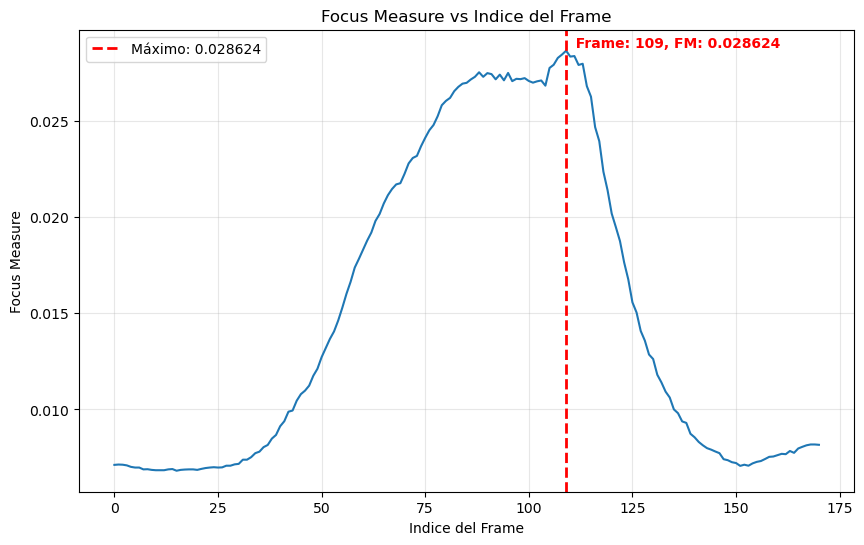

Valor máximo del índice de enfoque: 0.028624 en el frame 109, valores_above_threshold: 46


In [27]:
# 1) Calcular y plotear los valores del índice de enfoque a lo largo del tiempo para el video completo (sin aplicar sharpening)
data_full_no_sharpen = calculate_fm_from_video('focus_video.mov', frame_percentage=1.0, sharp_image=False)

plot_fm_values(data_full_no_sharpen.get('fm_values'))

print(f"Valor máximo del índice de enfoque: {data_full_no_sharpen.get('max_fm_value'):.6f} en el frame {data_full_no_sharpen.get('max_fm_index')}, valores_above_threshold: {data_full_no_sharpen.get('values_above_threshold')}")


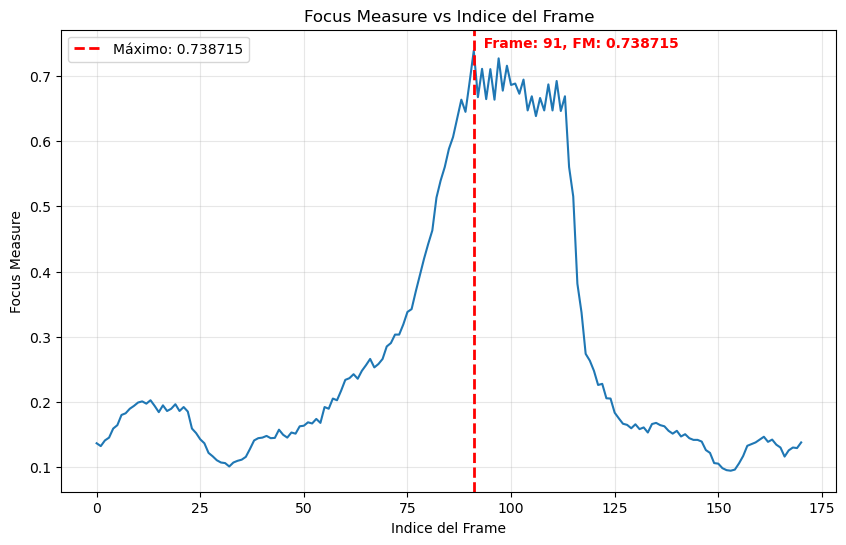

Valor máximo del índice de enfoque (subimagen 10.0%): 0.738715 en el frame 91, valores_above_threshold: 28


In [29]:
# 2) Calcular y plotear los valores del índice de enfoque a lo largo del tiempo para el video completo pero utilizando solo 
#    una subimagen centrada del 10% de la imagen original (sin aplicar sharpening)
frame_percentage = 0.1

data_per_no_sharpen = calculate_fm_from_video('focus_video.mov', frame_percentage=frame_percentage, sharp_image=False)

plot_fm_values(data_per_no_sharpen.get('fm_values'))

print(f"Valor máximo del índice de enfoque (subimagen {frame_percentage*100}%): {data_per_no_sharpen.get('max_fm_value'):.6f} en el frame {data_per_no_sharpen.get('max_fm_index')}, valores_above_threshold: {data_per_no_sharpen.get('values_above_threshold')}")


Skipping max fm frame: 109


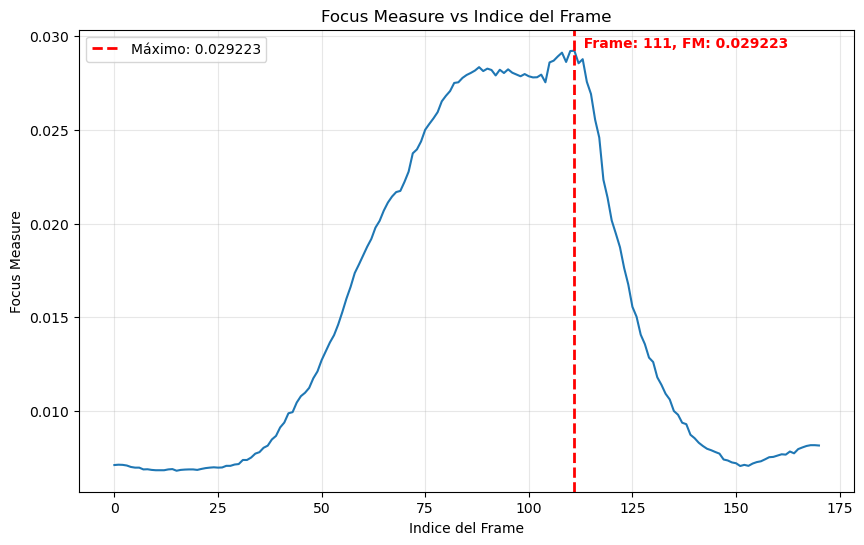

Valor máximo del índice de enfoque: 0.028624 en el frame 109, valores_above_threshold: 46
Numero de frames mejorados: 45


In [30]:
# 3) Calcular y plotear los valores del índice de enfoque a lo largo del tiempo para el video completo  (aplicar sharpening)
# Nota1: solo se va a aplicar el sharpening a los frames cuya metrica fm_value este por encima de fm_value_max * (1-0.20)
# Nota2: al maximo frame NO se le aplica sharpening
data_full_sharpen = calculate_fm_from_video('focus_video.mov', frame_percentage=1.0, sharp_image=True, thres = 0.20)

plot_fm_values(data_full_sharpen.get('fm_values'))

print(f"Valor máximo del índice de enfoque: {data_full_sharpen.get('max_fm_value'):.6f} en el frame {data_full_sharpen.get('max_fm_index')}, valores_above_threshold: {data_full_sharpen.get('values_above_threshold')}")

print(f"Numero de frames mejorados: {len(data_full_sharpen.get('sharpen_indexes'))}")